In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [3]:
from scipy.stats import skew

# ---------------------------------------------------------
# 1. Load & sanity-check
# ---------------------------------------------------------
df = pd.read_csv('insurance_medical_cost_cleaned.csv')

print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nHead:")
print(df.head())

print("\nUnique values check:")
print("sex:", df['sex'].unique())
print("smoker:", df['smoker'].unique())


Shape: (1338, 9)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   age               1338 non-null   int64  
 1   sex               1338 non-null   int64  
 2   bmi               1338 non-null   float64
 3   children          1338 non-null   int64  
 4   smoker            1338 non-null   int64  
 5   charges           1338 non-null   float64
 6   region_northwest  1338 non-null   int64  
 7   region_southeast  1338 non-null   int64  
 8   region_southwest  1338 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 94.2 KB

Head:
   age  sex    bmi  children  smoker   charges  region_northwest  \
0   56    0  27.02         2       0  23156.27                 1   
1   46    1  29.40         1       0  19456.82                 0   
2   32    0  25.97         5       0  20395.06                 1   
3   60    0  30.80         1      

In [4]:
# ---------------------------------------------------------
# 2. Summary statistics
# ---------------------------------------------------------
print("\n--- Describe (all numeric columns) ---")
print(df.describe())

print("\n--- Median (key columns) ---")
print(df[['age', 'bmi', 'charges']].median())

print("\n--- IQR (key columns) ---")
for col in ['age', 'bmi', 'charges']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"{col}: Q1={q1:.2f}, Q3={q3:.2f}, IQR={iqr:.2f}")



--- Describe (all numeric columns) ---
               age          sex          bmi     children       smoker  \
count  1338.000000  1338.000000  1338.000000  1338.000000  1338.000000   
mean     41.036622     0.493274    30.448475     1.092676     0.207773   
std      13.528861     0.500142     5.966884     1.228710     0.405865   
min      18.000000     0.000000    15.960000     0.000000     0.000000   
25%      29.000000     0.000000    26.332500     0.000000     0.000000   
50%      42.000000     0.000000    30.620000     1.000000     0.000000   
75%      52.000000     1.000000    34.510000     2.000000     0.000000   
max      64.000000     1.000000    47.260000     5.000000     1.000000   

            charges  region_northwest  region_southeast  region_southwest  
count   1338.000000       1338.000000       1338.000000       1338.000000  
mean   26947.834066          0.256353          0.248879          0.243647  
std    12996.479469          0.436782          0.432525          

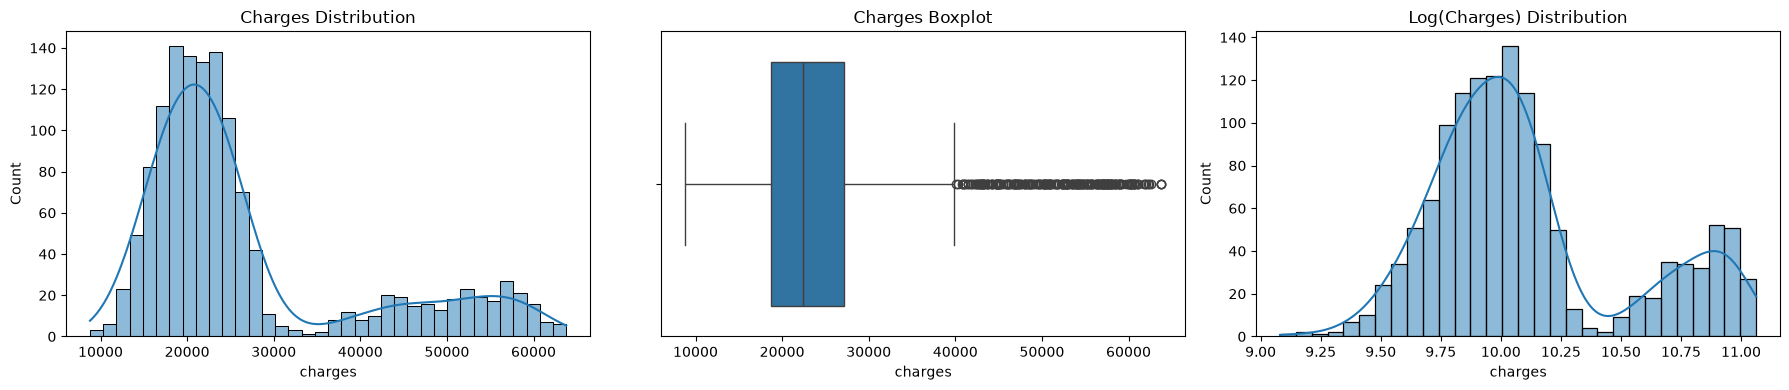


Skewness of charges: 1.371
Skewness of log(charges): 0.806


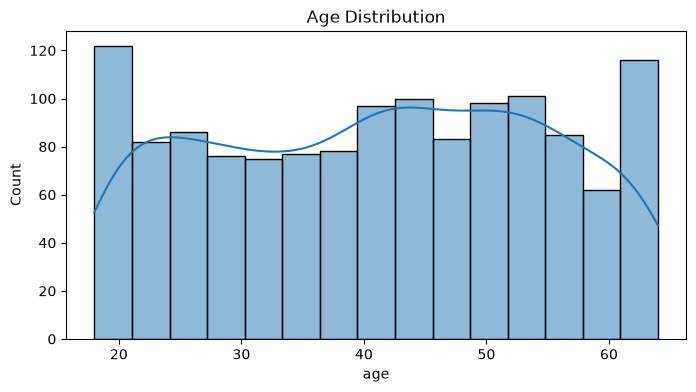


Age group counts:
age_group
18-30    366
31-40    264
41-50    321
51-65    387
Name: count, dtype: int64


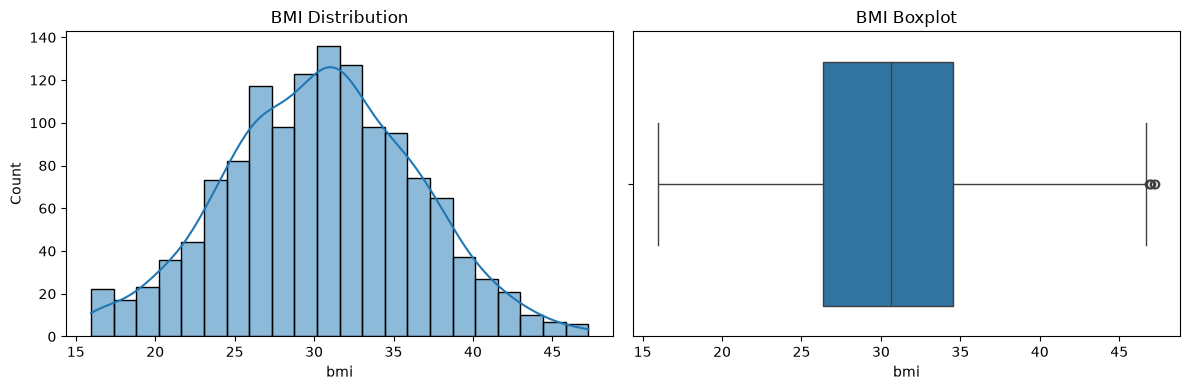


Skewness of bmi: 0.005

BMI category counts:
bmi_category
Obese          717
Overweight     379
Normal         209
Underweight     33
Name: count, dtype: int64


In [6]:
# ---------------------------------------------------------
# 3. Distribution analysis
# ---------------------------------------------------------

# --- charges: histogram, boxplot, skewness ---
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.histplot(df['charges'], kde=True, ax=axes[0])
axes[0].set_title('Charges Distribution')

sns.boxplot(x=df['charges'], ax=axes[1])
axes[1].set_title('Charges Boxplot')

sns.histplot(np.log(df['charges']), kde=True, ax=axes[2])
axes[2].set_title('Log(Charges) Distribution')
plt.tight_layout()
plt.show()

print(f"\nSkewness of charges: {skew(df['charges']):.3f}")
print(f"Skewness of log(charges): {skew(np.log(df['charges'])):.3f}")

# --- age: histogram + age groups ---
plt.figure(figsize=(8, 4))
sns.histplot(df['age'], bins=15, kde=True)
plt.title('Age Distribution')
plt.show()

df['age_group'] = pd.cut(df['age'], bins=[17, 30, 40, 50, 65],
                          labels=['18-30', '31-40', '41-50', '51-65'])
print("\nAge group counts:")
print(df['age_group'].value_counts().sort_index())

# --- bmi: histogram + boxplot + WHO categories ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bmi'], kde=True, ax=axes[0])
axes[0].set_title('BMI Distribution')
sns.boxplot(x=df['bmi'], ax=axes[1])
axes[1].set_title('BMI Boxplot')
plt.tight_layout()
plt.show()

print(f"\nSkewness of bmi: {skew(df['bmi']):.3f}")

df['bmi_category'] = pd.cut(df['bmi'], bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])
print("\nBMI category counts:")
print(df['bmi_category'].value_counts())


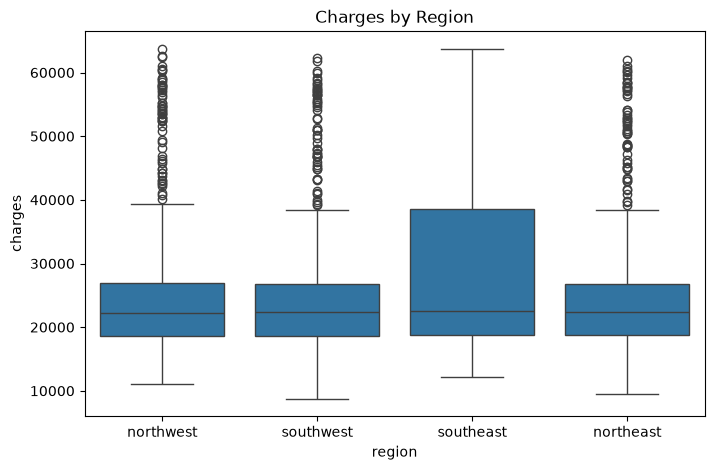


Charges by region:
           count          mean           std       min         25%        50%  \
region                                                                          
northeast  336.0  26337.418810  12394.934161   9421.76  18701.0725  22420.110   
northwest  343.0  26649.418601  12947.375974  11026.53  18588.4650  22254.210   
southeast  333.0  28373.406967  14136.120245  12135.05  18743.6800  22552.190   
southwest  326.0  26434.767362  12374.946982   8783.15  18676.7200  22304.505   

                  75%       max  
region                           
northeast  26850.8425  61960.43  
northwest  26933.2100  63770.43  
southeast  38558.6200  63770.43  
southwest  26736.9275  62266.30  


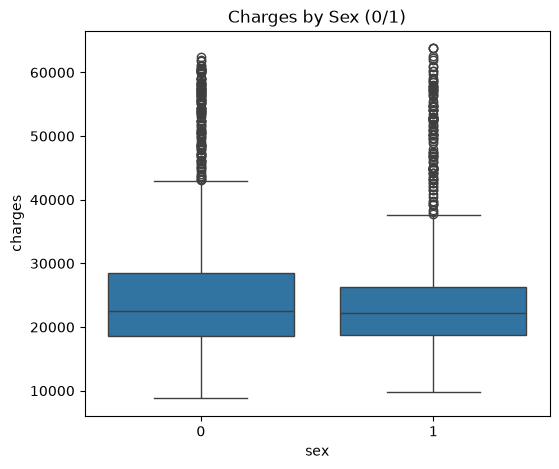


Charges by sex:
     count          mean           std      min         25%        50%  \
sex                                                                      
0    678.0  27748.009853  13650.086324  8783.15  18667.6675  22553.050   
1    660.0  26125.835303  12244.886647  9759.64  18693.7175  22232.405   

            75%       max  
sex                        
0    28460.2125  62394.44  
1    26336.9800  63770.43  


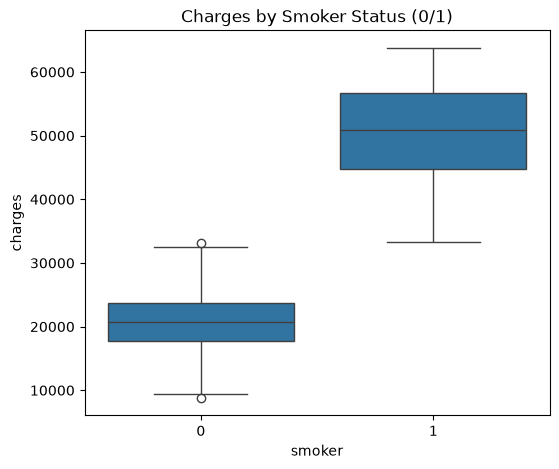


Charges by smoker status:
         count          mean          std       min         25%        50%  \
smoker                                                                       
0       1060.0  20779.834538  4069.557618   8783.15  17790.9225  20734.725   
1        278.0  50466.105647  7160.113002  33305.01  44832.3825  50948.215   

               75%       max  
smoker                        
0       23734.1350  33075.95  
1       56642.1275  63770.43  


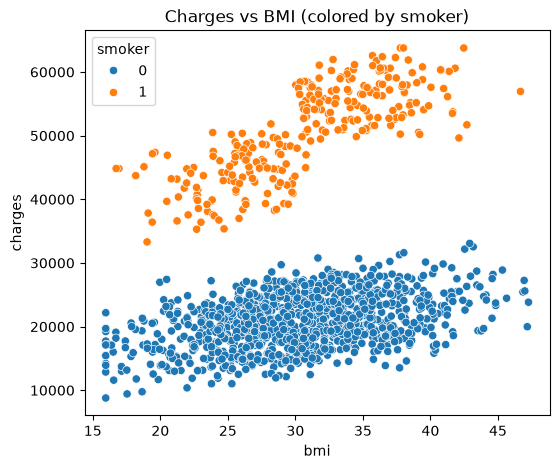

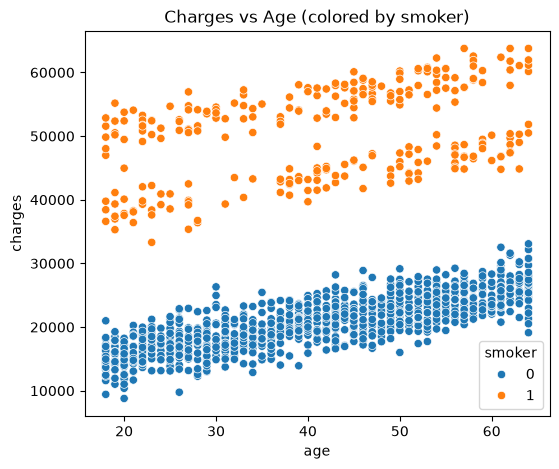

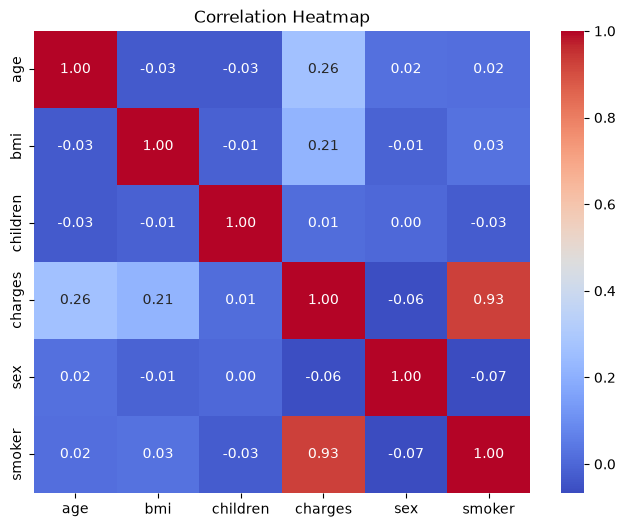

In [7]:

# ---------------------------------------------------------
# 4. Relationships between variables
# ---------------------------------------------------------

# Reconstruct a single 'region' column from one-hot columns
def get_region(row):
    if row['region_northwest'] == 1:
        return 'northwest'
    elif row['region_southeast'] == 1:
        return 'southeast'
    elif row['region_southwest'] == 1:
        return 'southwest'
    else:
        return 'northeast'  # baseline dropped column

df['region'] = df.apply(get_region, axis=1)

# --- charges vs region ---
plt.figure(figsize=(8, 5))
sns.boxplot(x='region', y='charges', data=df)
plt.title('Charges by Region')
plt.show()
print("\nCharges by region:")
print(df.groupby('region')['charges'].describe())

# --- charges vs sex ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='sex', y='charges', data=df)
plt.title('Charges by Sex (0/1)')
plt.show()
print("\nCharges by sex:")
print(df.groupby('sex')['charges'].describe())

# --- charges vs smoker (strongest relationship usually) ---
plt.figure(figsize=(6, 5))
sns.boxplot(x='smoker', y='charges', data=df)
plt.title('Charges by Smoker Status (0/1)')
plt.show()
print("\nCharges by smoker status:")
print(df.groupby('smoker')['charges'].describe())

# --- charges vs bmi (scatter) ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x='bmi', y='charges', hue='smoker', data=df)
plt.title('Charges vs BMI (colored by smoker)')
plt.show()

# --- charges vs age (scatter) ---
plt.figure(figsize=(6, 5))
sns.scatterplot(x='age', y='charges', hue='smoker', data=df)
plt.title('Charges vs Age (colored by smoker)')
plt.show()

# --- correlation heatmap ---
plt.figure(figsize=(8, 6))
numeric_cols = ['age', 'bmi', 'children', 'charges', 'sex', 'smoker']
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()